In [1]:
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, TargetEncoder,
    StandardScaler, MinMaxScaler, RobustScaler,
    PolynomialFeatures
)

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, QuantileRegressor
)

from sklearn.metrics import (
    r2_score,
    root_mean_squared_error as rmse,
    mean_absolute_percentage_error as mape,
)

In [2]:
from sklearn.compose import (
    ColumnTransformer
)

from sklearn.impute import (
    SimpleImputer
)

In [5]:
import pandas as pd
import numpy as np
import sklearn


df = pd.read_csv("../../data/data_transformed_main.csv").set_index(["ID на сайте", "Источник"])
df["Вид объекта"] = df["Вид объекта"].replace({
    'Офис/Здание': 'Офис / Здание',
    'Торговое / Свободное назначение': 'Торговое / Свободного назначения',
    'Торговое / свободного вида': 'Торговое / Свободного назначения',
    'Торговое/Свободного назначения': 'Торговое / Свободного назначения',
})
df["Москва?"] = df["Москва?"].replace({'False': 0, 'True': 1}).astype(float)
df.head()

,,Цена,Дата,Тип автора,Город,Метро/Район,Адрес,Описание,lat,lng,URL,Ссылки на картинки,"Расстояние до метро, км",Этаж,Этажность здания,Вид объекта,Общая площадь,Цена / м2,Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,
321970859,cian.ru,34500.0,2025-12-17 08:36:40,Агентство,Химки,Беломорская,"Рабочая ул., 2","НАЗВАНИЕ: Офис в Московская область, Химки Раб...",55.908036,37.432951,https://www.cian.ru/rent/commercial/321970859,https://images.cdn-cian.ru/images/2633983674-1...,9.167,4.0,4.0,Офис / Здание,23.0,1500.0,0.0
323570959,cian.ru,160500.0,2025-12-17 08:36:40,Частное лицо,Солнечногорск городской округ,Зеленоград — Крюково,21А,НАЗВАНИЕ: Торговая площадь в Московская област...,55.972650,37.099604,https://www.cian.ru/rent/commercial/323570959,https://images.cdn-cian.ru/images/torgovoe-pom...,9.167,1.0,1.0,Торговое / Свободного назначения,107.0,1500.0,0.0
319937619,cian.ru,1226740.0,2025-12-17 08:36:40,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319937619,https://images.cdn-cian.ru/images/2634163777-1...,9.167,2.0,6.0,Офис / Здание,830.0,1478.0,0.0
319936797,cian.ru,236480.0,2025-12-17 08:36:39,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319936797,https://images.cdn-cian.ru/images/2634163921-1...,9.167,2.0,6.0,Офис / Здание,160.0,1478.0,0.0
319938233,cian.ru,1537120.0,2025-12-17 08:36:38,Агентство,Мытищи,Медведково,"ул. Колпакова, 46А","НАЗВАНИЕ: Офис в Московская область, Мытищи ул...",55.925178,37.718300,https://www.cian.ru/rent/commercial/319938233,https://images.cdn-cian.ru/images/2569099478-1...,9.167,2.0,6.0,Офис / Здание,1040.0,1478.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 29559 entries, (np.int64(321970859), 'cian.ru') to (np.int64(4937488939), 'avito.ru')
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Цена                     29559 non-null  float64
 1   Дата                     29559 non-null  object 
 2   Тип автора               29559 non-null  object 
 3   Город                    29559 non-null  object 
 4   Метро/Район              22098 non-null  object 
 5   Адрес                    29232 non-null  object 
 6   Описание                 29313 non-null  object 
 7   lat                      29559 non-null  float64
 8   lng                      29559 non-null  float64
 9   URL                      29559 non-null  object 
 10  Ссылки на картинки       29108 non-null  object 
 11  Расстояние до метро, км  20605 non-null  float64
 12  Этаж                     28639 non-null  float64
 13  Этажность здания

In [ ]:
from sklearn.model_selection import train_test_split

y = df["Цена"].copy()
X = df[["Общая площадь", "Расстояние до метро, км", "Вид объекта", "Тип автора", "Москва?", "Этаж", "Этажность здания"]].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=X["Вид объекта"])

In [6]:
ct1 = ColumnTransformer(
    transformers=[
        ("isna", SimpleImputer(strategy="constant", fill_value=1, add_indicator=True, copy=False), ["Расстояние до метро, км", "Этаж", "Этажность здания"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
    verbose_feature_names_out=False
).set_output(transform="pandas")
ct1.fit(X_train)

ct2 = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), ["Общая площадь", "Расстояние до метро, км"]),
        ("onehot", OneHotEncoder(sparse_output=False), ["Вид объекта"]),
        ("ordinal", OrdinalEncoder(), ["Тип автора"]),
    ],
    remainder="passthrough",
    n_jobs=-1,
    verbose_feature_names_out=False
).set_output(transform="pandas")
ct2.fit(ct1.transform(X_train))

ct3 = ColumnTransformer(
    transformers=[
        ("polynoms", PolynomialFeatures(degree=3), ["Общая площадь", "Расстояние до метро, км", "Этаж"]),
        # ("mult", PolynomialFeatures(degree=3), [["Общая площадь", "Этаж"]])
    ],
    remainder="passthrough",
    n_jobs=-1,
).set_output(transform="pandas")
ct3.fit(ct2.transform(ct1.transform(X_train)))

def transform_all(X):
    return ct3.transform(ct2.transform(ct1.transform(X)))

In [7]:
_ = transform_all(X_train)
_

,,polynoms__1,polynoms__Общая площадь,"polynoms__Расстояние до метро, км",polynoms__Этаж,polynoms__Общая площадь^2,"polynoms__Общая площадь Расстояние до метро, км",polynoms__Общая площадь Этаж,"polynoms__Расстояние до метро, км^2","polynoms__Расстояние до метро, км Этаж",polynoms__Этаж^2,...,"polynoms__Расстояние до метро, км Этаж^2",polynoms__Этаж^3,remainder__Вид объекта_Офис / Здание,remainder__Вид объекта_Торговое / Свободного назначения,remainder__Тип автора,remainder__Этажность здания,"remainder__missingindicator_Расстояние до метро, км",remainder__missingindicator_Этаж,remainder__missingindicator_Этажность здания,remainder__Москва?
ID на сайте,Источник,,,,,,,,,,,,,,,,,,,,,
6195426166634828293,realty.yandex.ru,1.0,0.458689,-0.621918,26.0,0.210396,-0.285267,11.925919,0.386782,-16.169872,676.0,...,-420.416676,17576.0,1.0,0.0,0.0,27.0,0.0,0.0,0.0,0.0
315163433,cian.ru,1.0,-0.142067,0.225338,1.0,0.020183,-0.032013,-0.142067,0.050777,0.225338,1.0,...,0.225338,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
322725690,cian.ru,1.0,0.660924,-0.756620,1.0,0.436820,-0.500068,0.660924,0.572473,-0.756620,1.0,...,-0.756620,1.0,0.0,1.0,0.0,5.0,0.0,0.0,0.0,0.0
7498640959,avito.ru,1.0,1.791059,-0.718150,1.0,3.207892,-1.286249,1.791059,0.515739,-0.718150,1.0,...,-0.718150,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
3255678710622496700,realty.yandex.ru,1.0,1.005585,4.990722,1.0,1.011202,5.018596,1.005585,24.907303,4.990722,1.0,...,4.990722,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7566006487,avito.ru,1.0,-0.606017,-0.718150,2.0,0.367256,0.435211,-1.212034,0.515739,-1.436300,4.0,...,-2.872600,8.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
6899847403718304817,realty.yandex.ru,1.0,3.069896,0.860723,2.0,9.424260,2.642329,6.139792,0.740843,1.721445,4.0,...,3.442890,8.0,1.0,0.0,0.0,17.0,0.0,0.0,0.0,0.0
2361989376876296498,realty.yandex.ru,1.0,-0.439471,0.225338,3.0,0.193135,-0.099030,-1.318412,0.050777,0.676014,9.0,...,2.028043,27.0,1.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0


In [50]:
from sklearn.feature_selection import SelectKBest, mutual_info_regression
skb = SelectKBest(mutual_info_regression, k=20).fit(ct3.transform(ct2.transform(ct1.transform(X_train))), y_train)

def transform_all(X):
    return skb.transform(ct3.transform(ct2.transform(ct1.transform(X))))

In [51]:
X_train_pre = transform_all(X_train)
X_test_pre = transform_all(X_test)

In [52]:
X_train_pre.shape

(22169, 20)

In [53]:
from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import (
    LinearSVR
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.kernel_ridge import KernelRidge

In [54]:
model = KNeighborsRegressor(
    n_neighbors=10,
).fit(X_train_pre, y_train)

# DecisionTreeRegressor(
#     max_depth=8
# )
# KNeighborsRegressor(
#     n_neighbors=5,
# )

In [55]:
y_train_pred = model.predict(X_train_pre)
y_test_pred = model.predict(X_test_pre)

In [56]:
r2_score(y_train, y_train_pred), rmse(y_train, y_train_pred), mape(y_train, y_train_pred)

(0.8165171417673415, 181338.4281237094, 0.4553633253200532)

In [57]:
r2_score(y_test, y_test_pred), rmse(y_test, y_test_pred), mape(y_test, y_test_pred)

(0.7801849310886666, 196823.6662081224, 0.503715906021602)

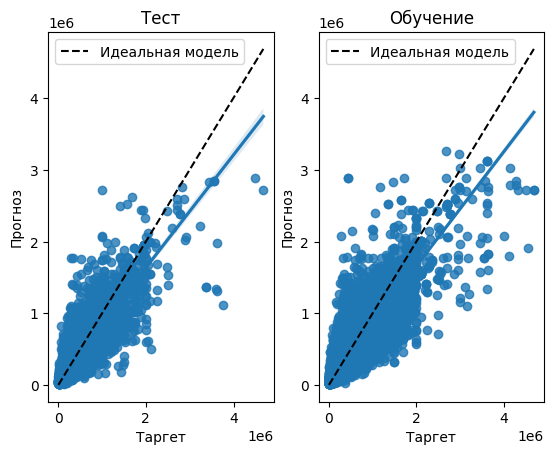

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axis = plt.subplots(ncols=2)
sns.regplot(x=y_test, y=y_test_pred, ax=axis[0])
sns.regplot(x=y_train, y=y_train_pred, ax=axis[1])

for i, y_true in enumerate([y_test, y_train]):
    lims = [np.min(y_true), np.max(y_true)]
    axis[i].plot(lims, lims, linestyle="--", color="black", label="Идеальная модель")

axis[0].set_title("Тест")
axis[1].set_title("Обучение")
for i in [0, 1]:
    axis[i].set_xlabel("Таргет")
    axis[i].set_ylabel("Прогноз")
    axis[i].legend()
plt.show()